# Styles showcase

Full charts under every shipped style, a stock matplotlib stylesheet, and a custom style dict. Every chart uses exactly one *total* style — ambient rcParams never affect the result. `style=None` resolves the `mplchart` style; `style="default"` is matplotlib's factory look (they differ by exactly two grid keys: `axes.grid`, `grid.alpha`).

In [1]:
from mplchart.chart import Chart
from mplchart.indicators import MACD, RSI, SMA
from mplchart.primitives import Candlesticks, LinePlot, Pane, Volume
from mplchart.samples import sample_prices
from mplchart.styles import available_styles

prices = sample_prices()
available_styles()

['cascade', 'chartist', 'modern', 'mplchart', 'nightclouds']

In [2]:
def show_style(prices, style=None, title=None):
    """Render the full typical-usage chart under one style."""
    title = title if title is not None else f"style={style!r}"
    (Chart(prices, title=title, max_bars=250, style=style)
        .plot(
            Candlesticks(), Volume(), SMA(50), SMA(200),
            Pane("above", yticks=(30, 50, 70)),
            LinePlot(RSI(), overbought=70, oversold=30),
            Pane("below"),
            MACD(),
        )
        .show()
    )

## Shipped styles

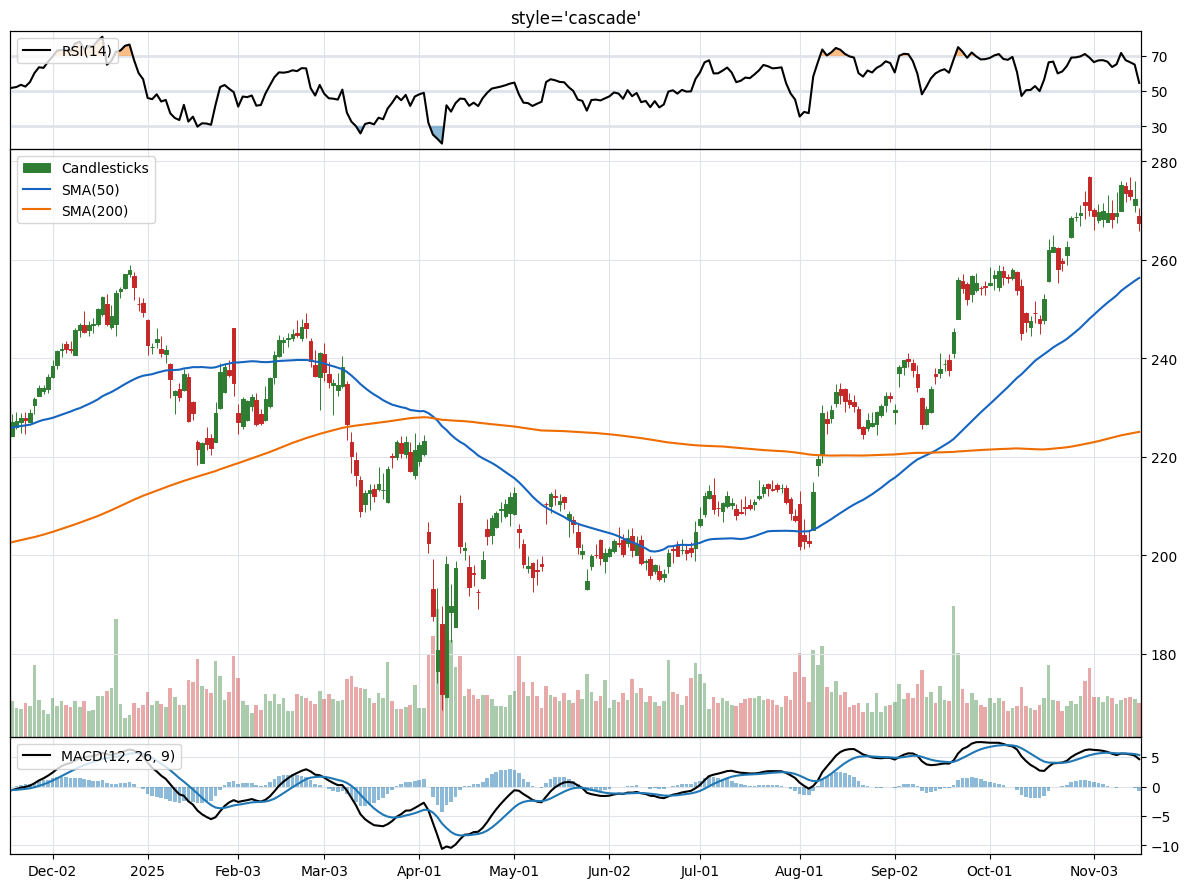

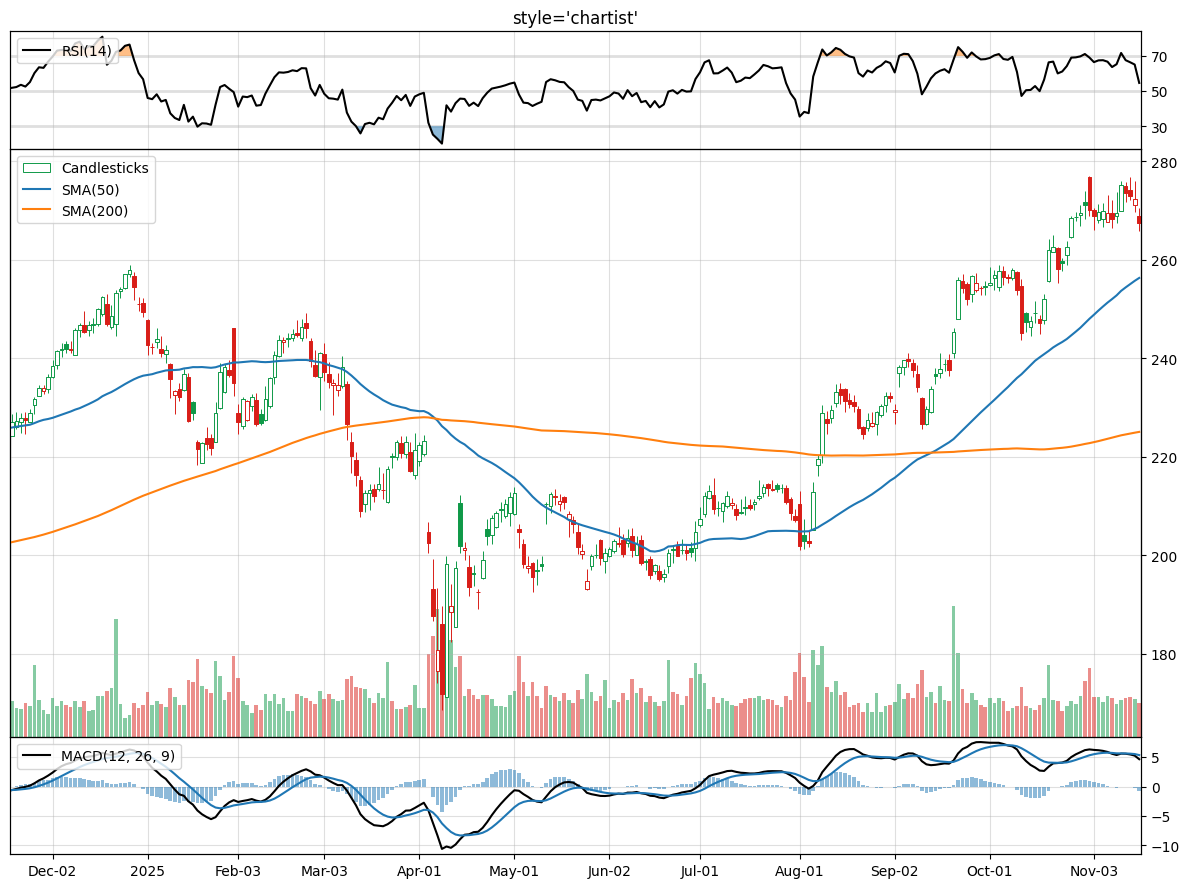

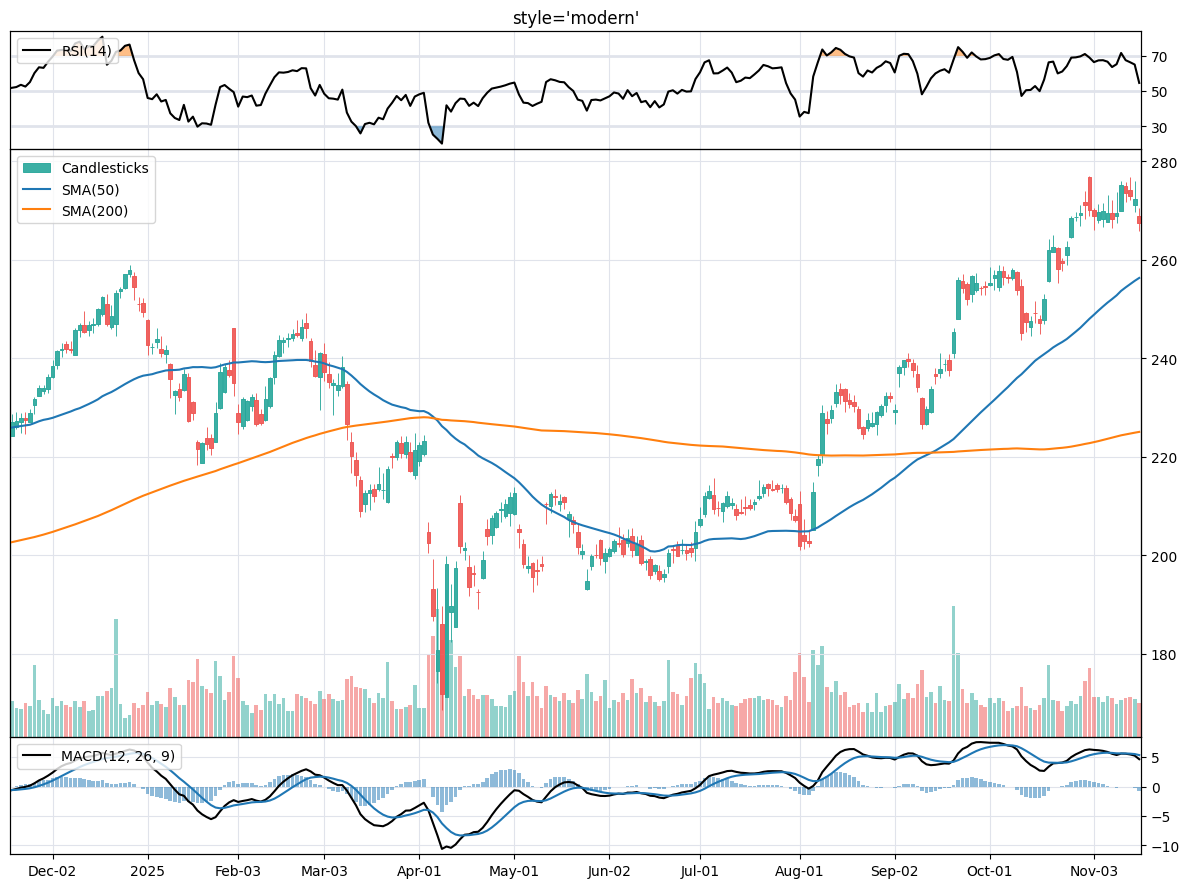

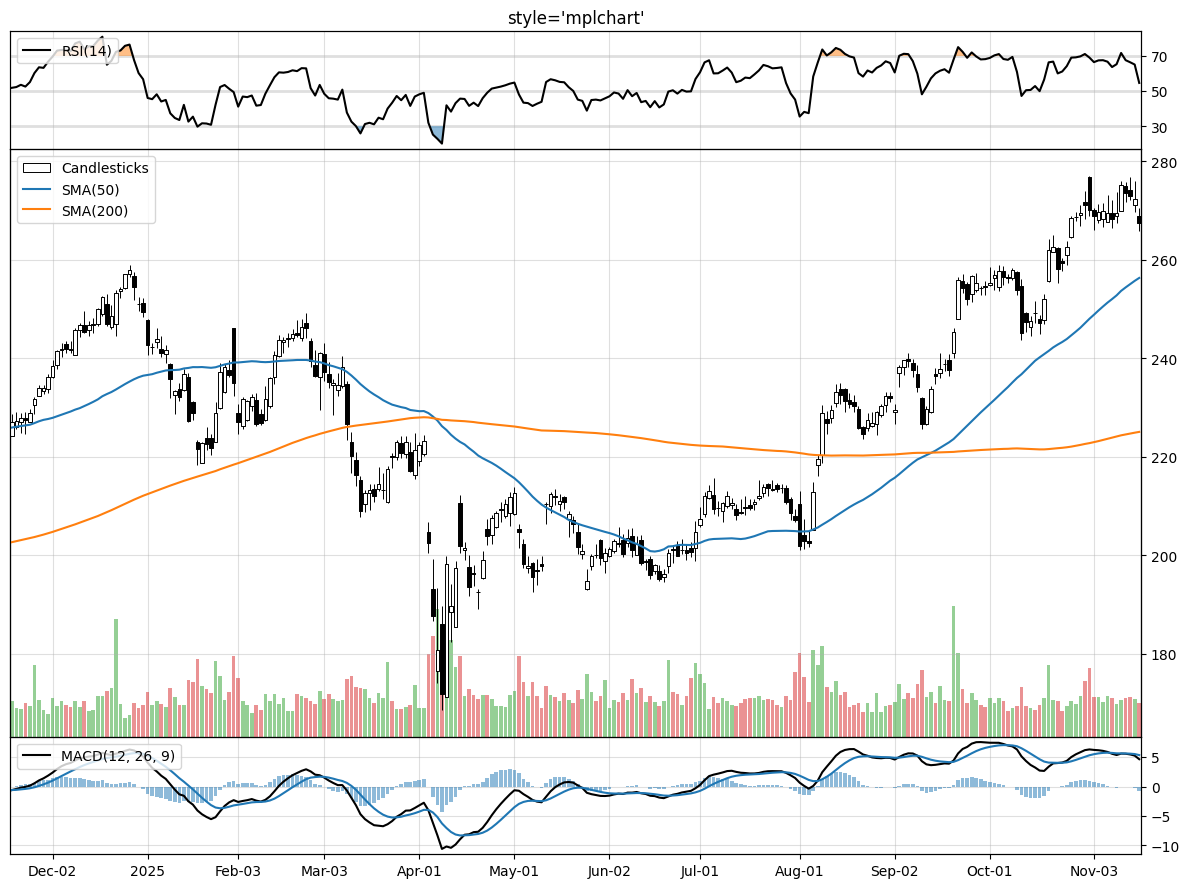

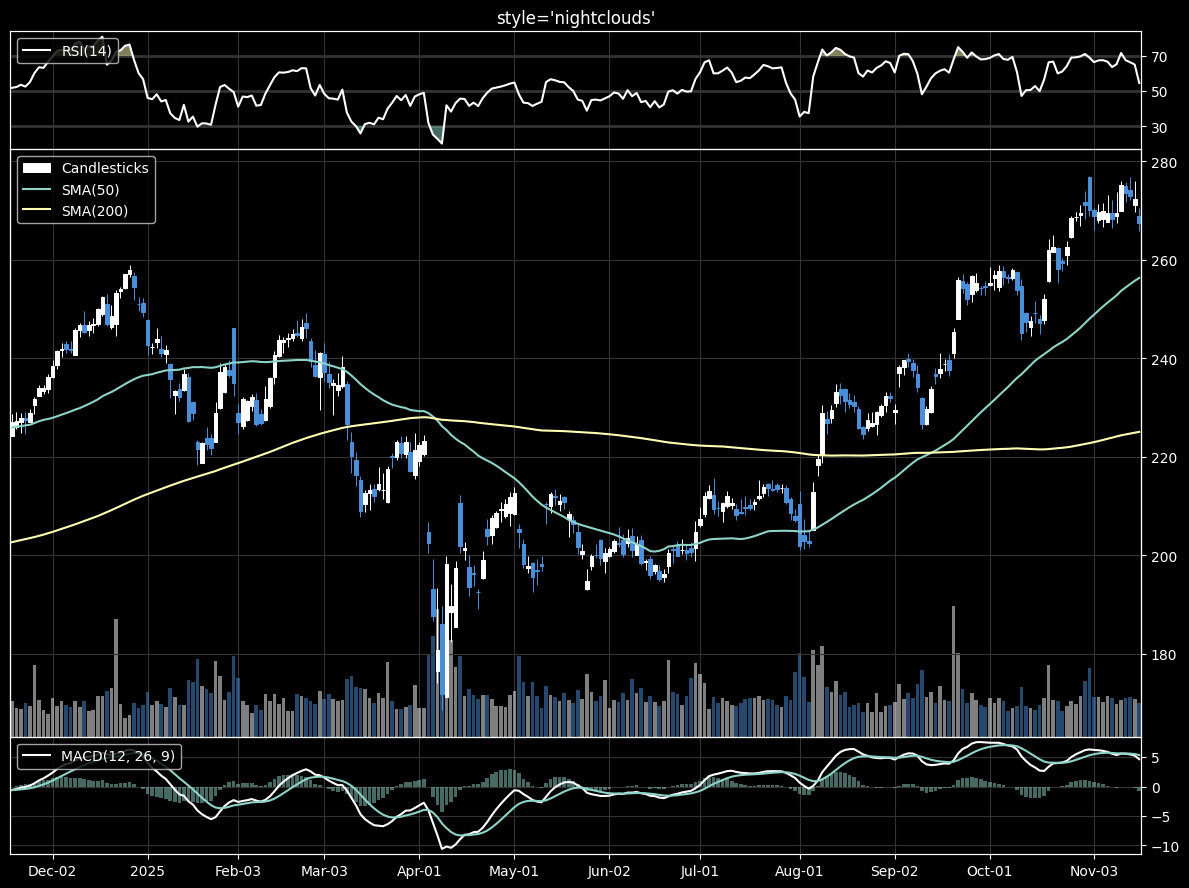

In [3]:
for name in available_styles():
    show_style(prices, style=name)

## Matplotlib stylesheets as styles

Any stylesheet name `plt.style.use` accepts works as a complete look — no mplchart opinions ride along (the sheet's own grid, or none).

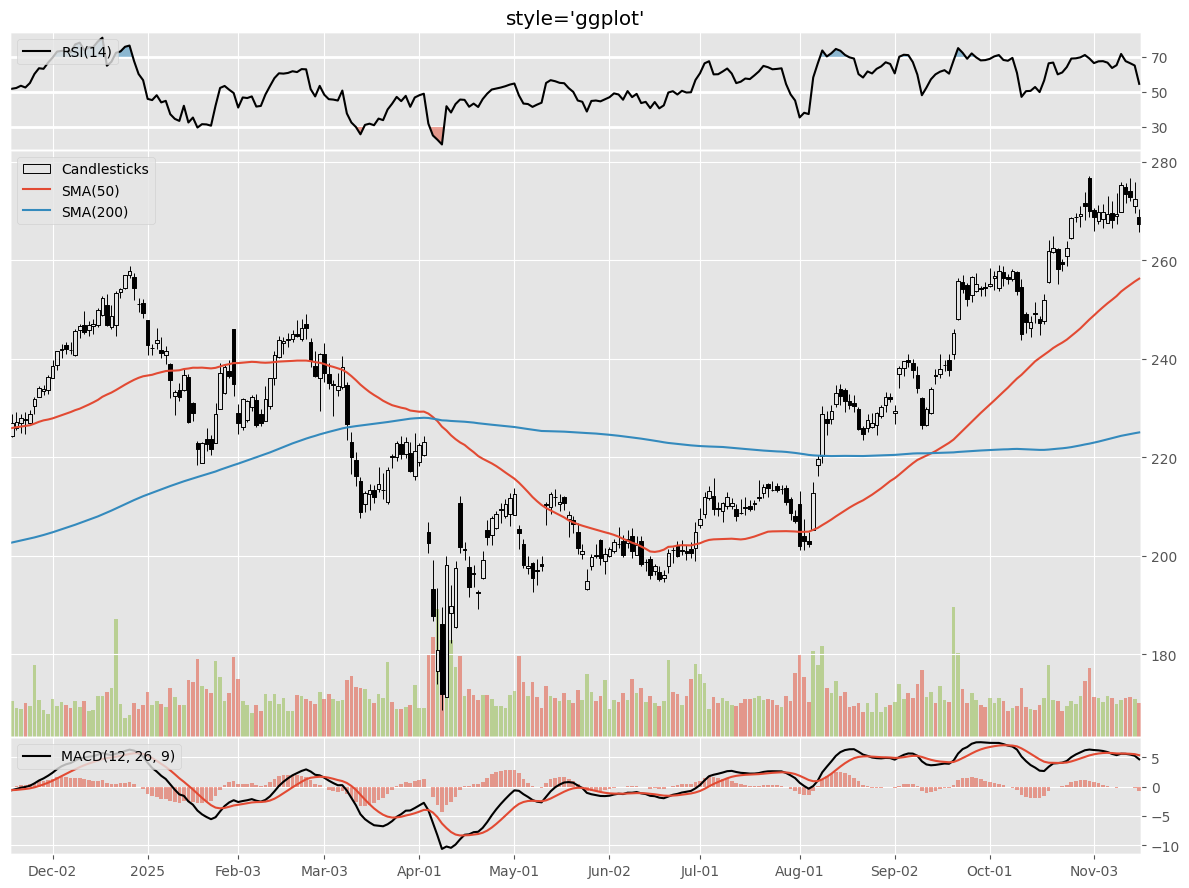

In [4]:
show_style(prices, style="ggplot")

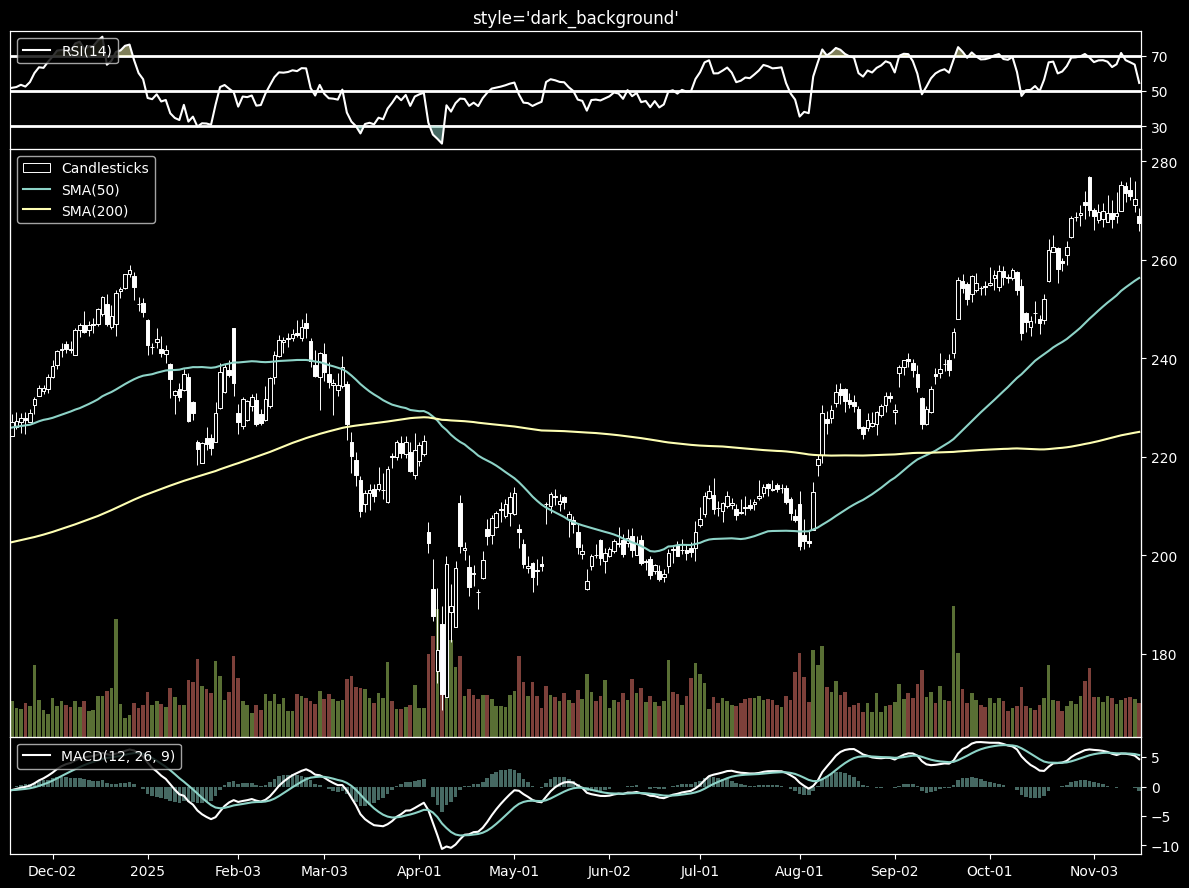

In [5]:
show_style(prices, style="dark_background")

## Custom style dict

The same schema as the shipped modules: optional `stylesheet` base, `rc` overrides, `settings` for the chart palette.

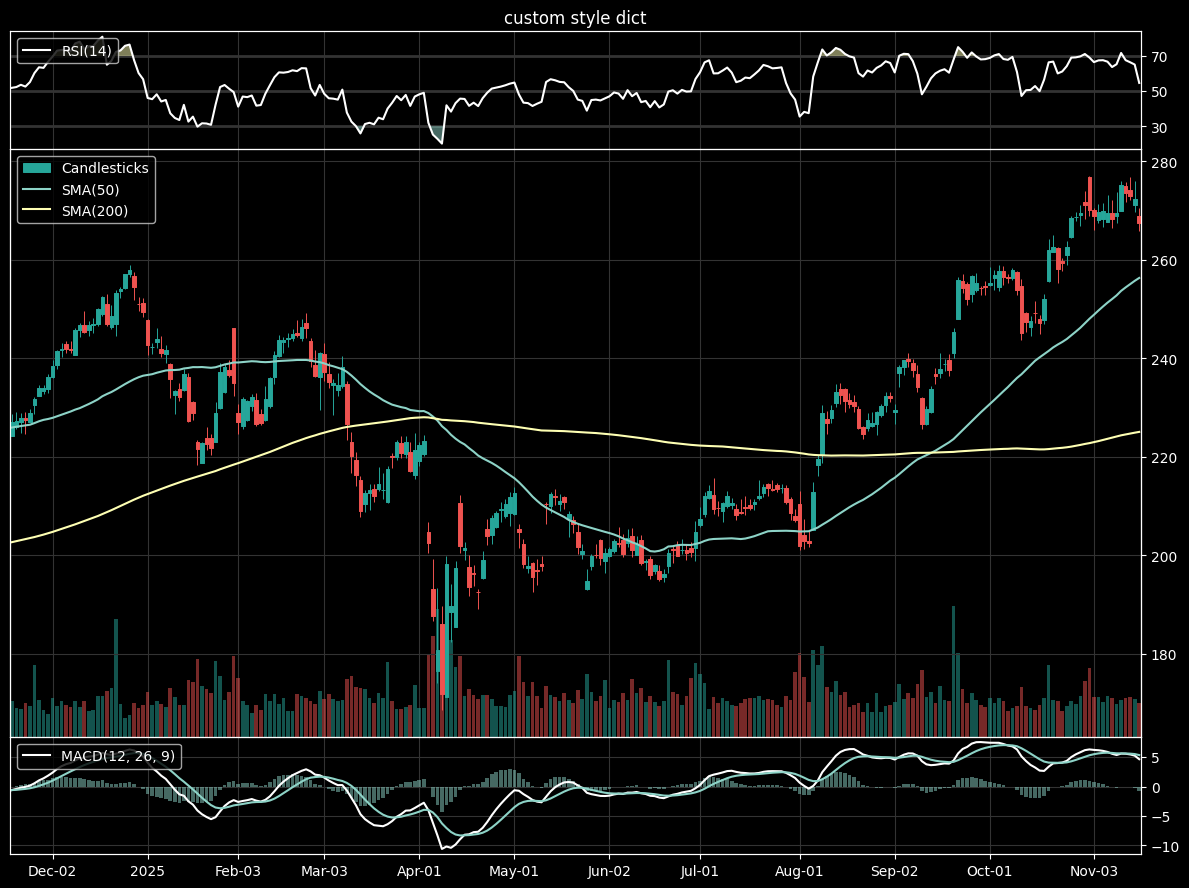

In [6]:
MY_STYLE = {
    "stylesheet": "dark_background",
    "rc": {"axes.grid": True, "grid.color": "#333333", "grid.alpha": 1.0},
    "settings": {
        "candle.up.color": "#26a69a",
        "candle.down.color": "#ef5350",
        "volume.up.color": "#26a69a",
        "volume.down.color": "#ef5350",
    },
}

show_style(prices, style=MY_STYLE, title="custom style dict")